In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import r2_score


In [114]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Machine learning\student_productivity_distraction_dataset_20000.csv")
df

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06


## Preprocessing Dataset

In [115]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score'],
      dtype='object')

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

In [117]:
df.shape

(20000, 18)

In [118]:
df.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [119]:
df.duplicated().sum()

np.int64(0)

In [120]:
df.isna().sum()

student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64

In [121]:
df['gender'].unique()
#missing data

array(['Female', 'Male', 'Other'], dtype=object)

In [122]:
# missing value when gender == other 
df[df['gender']=='Other'].shape

(778, 18)

In [123]:
df['gender'] = df['gender'].replace('Other', np.nan)

In [124]:
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_9740\1062339567.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna(df['gender'].mode()[0], inplace=True)


In [125]:
df.drop(["student_id"], axis=1, inplace=True)

## Feature Engineering

In [126]:
# missing time per day
df['missing-time']= df['social_media_hours'] + df['gaming_hours'] + df['phone_usage_hours']

In [127]:
# Percentage of time wasted compared to the study
df["distraction_ratio"] = df["missing-time"] / df["study_hours_per_day"] 

In [128]:
# convert exercise_minutes to hours
df["exercise_inhours"] = df["exercise_minutes"] / 60

In [129]:
# dropping features which already used in feature engineering
df.drop(["social_media_hours", "gaming_hours", "phone_usage_hours","exercise_minutes"], axis=1, inplace=True)

In [130]:
# student_efficiency
df["study_efficiency"] = df["study_hours_per_day"] * df["focus_score"]
df

,age,gender,study_hours_per_day,sleep_hours,youtube_hours,breaks_per_day,coffee_intake_mg,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score,missing-time,distraction_ratio,exercise_inhours,study_efficiency
0,23,Female,4.35,3.63,1.83,6,347,2,57.21,10,57,81.87,33.78,11.37,2.613793,1.850000,247.95
1,20,Male,6.14,6.58,3.13,13,403,10,91.27,10,49,60.90,48.99,8.72,1.420195,0.466667,300.86
2,29,Female,4.98,3.26,0.18,1,419,8,63.14,2,38,86.22,36.60,13.17,2.644578,1.700000,189.24
3,27,Female,3.19,4.58,5.75,9,178,18,40.51,6,50,71.77,19.87,16.53,5.181818,0.466667,159.50
4,24,Male,7.67,6.21,5.46,8,436,7,45.53,6,41,90.13,52.90,10.26,1.337679,1.750000,314.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,26,Female,4.81,7.83,2.77,6,451,11,63.69,3,89,82.13,60.43,19.47,4.047817,0.000000,428.09
19996,22,Female,0.83,4.49,2.95,1,375,4,74.06,10,56,87.12,17.84,11.93,14.373494,0.216667,46.48
19997,25,Male,9.36,4.33,0.35,4,413,11,73.18,9,69,81.58,65.56,11.34,1.211538,0.016667,645.84
19998,22,Female,0.74,4.44,3.11,7,319,6,77.02,5,53,53.04,28.06,14.15,19.121622,0.016667,39.22


## Visualization Dataset (EDA)

#### What does the distribution of productivity scores look like across students? 

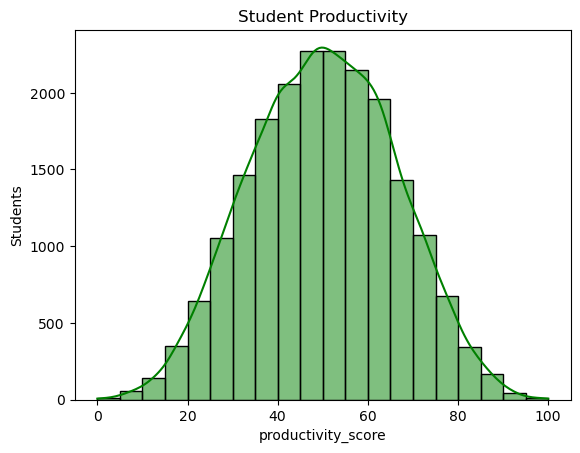

In [131]:
sns.histplot(df["productivity_score"], kde=True ,color="green", bins= 20 )
plt.title("Student Productivity")
plt.xlabel("productivity_score")
plt.ylabel('Students')
plt.show()

# There is a difference in productivity rates among students.
# Normal distribution 


#### What are the  potential outliers for each numeric feature in the dataset?

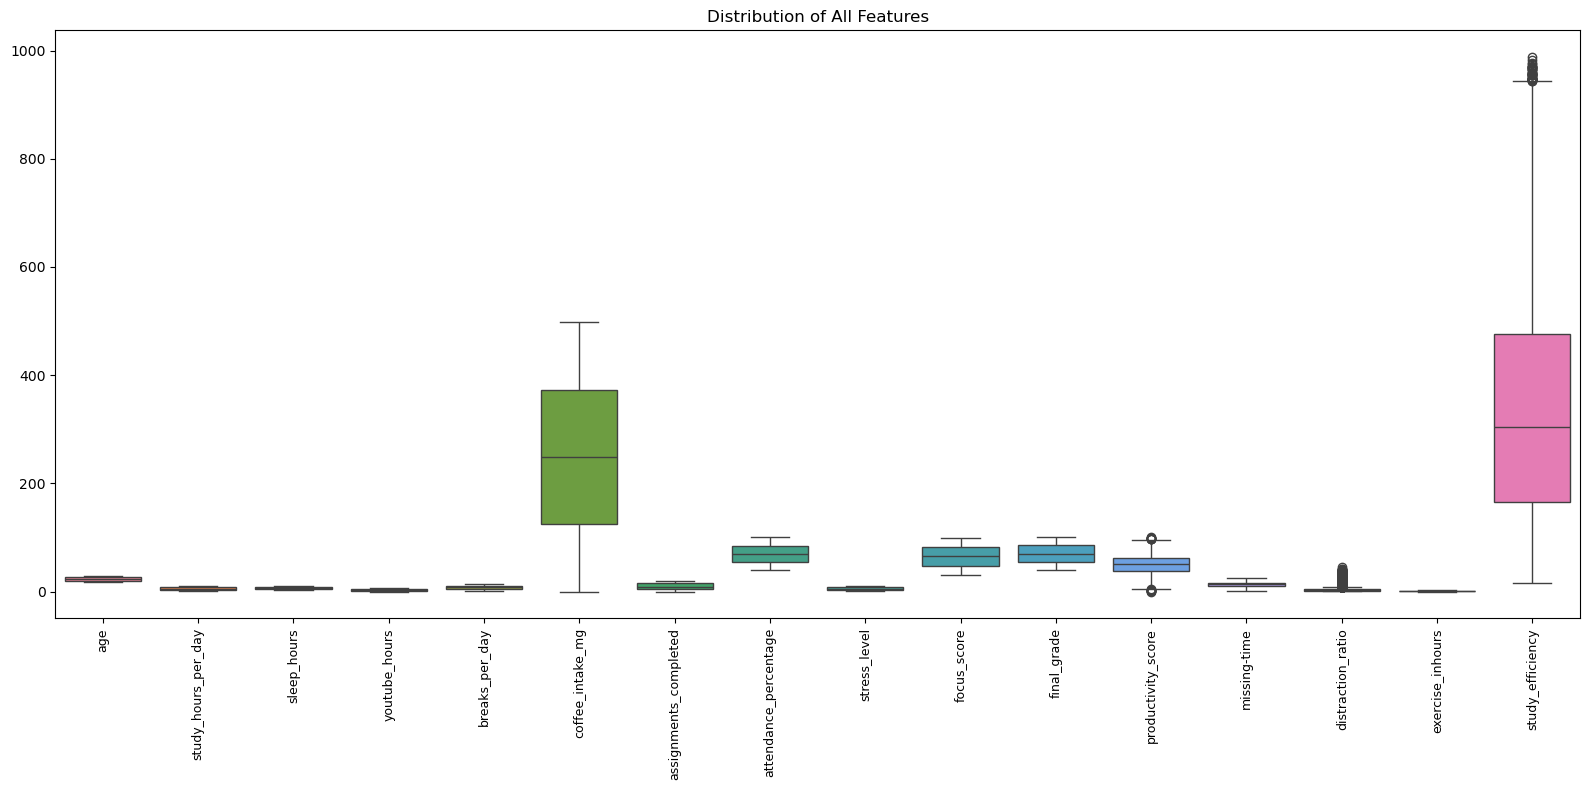

In [132]:
# checking features distribution and outliers
plt.figure(figsize=(16, 8))
sns.boxplot(data=df)
plt.xticks(rotation=90, fontsize=9)
plt.title('Distribution of All Features')
plt.tight_layout()
plt.show()


#### How is focus score related to study efficiency? Is there a strong positive trend?

Text(0.5, 1.0, 'the study efficiency due to focus score')

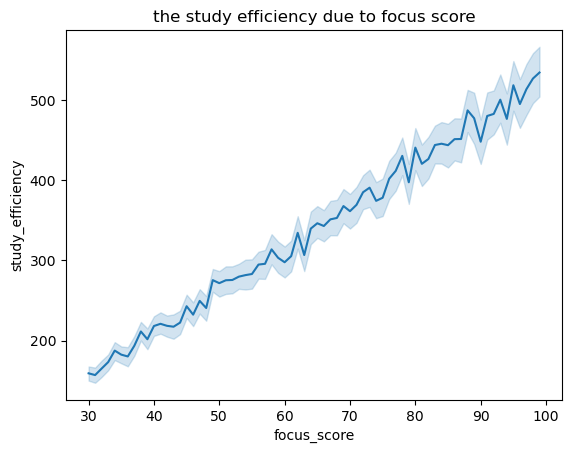

In [133]:
#there is Direct relationship between focus_score and study_efficiency


sns.lineplot(x="focus_score",y="study_efficiency",data=df)

plt.title("the study efficiency due to focus score")

#### How does the number of daily study hours influence productivity score?

Text(0.5, 0, 'Study Hours')

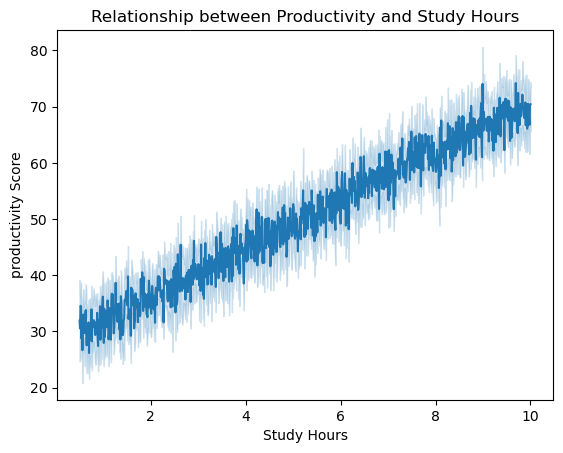

In [134]:
# positive relationship 
sns.lineplot(x= "study_hours_per_day", y= 'productivity_score', data=df)
plt.title("Relationship between Productivity and Study Hours")
plt.ylabel("productivity Score")
plt.xlabel('Study Hours')


####  Are there noticeable differences between males and females?

Text(0.5, 1.0, 'the productivity score due to age')

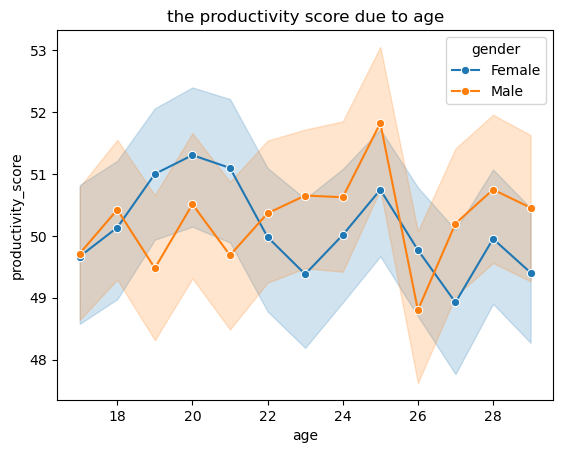

In [135]:
#Productivity doesn't increase or decrease steadily with age from 18 to 28
# meaning age alone doesn't significantly affect productivity in this data
# males : 24:26 high productivity
#females: 20:22 high productivity

sns.lineplot(x= "age",y= "productivity_score", data=df, hue='gender', marker='o')
plt.title("the productivity score due to age")

#### What is the relationship between stress level and productivity score? Does higher stress tend to lower productivity?

Text(0, 0.5, 'productivity Score')

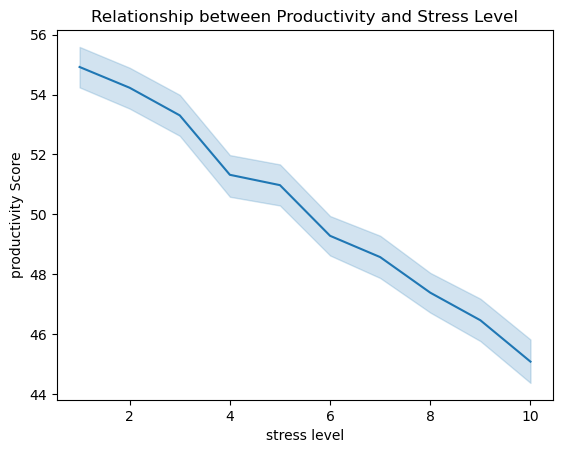

In [136]:
# Inverse relationship

sns.lineplot(x= "stress_level", y='productivity_score' , data=df)
plt.title("Relationship between Productivity and Stress Level")
plt.xlabel('stress level')
plt.ylabel("productivity Score")

#### How does the distraction ratio affect study efficiency?

Text(0.5, 1.0, 'the study_efficiency according to distraction_ratio')

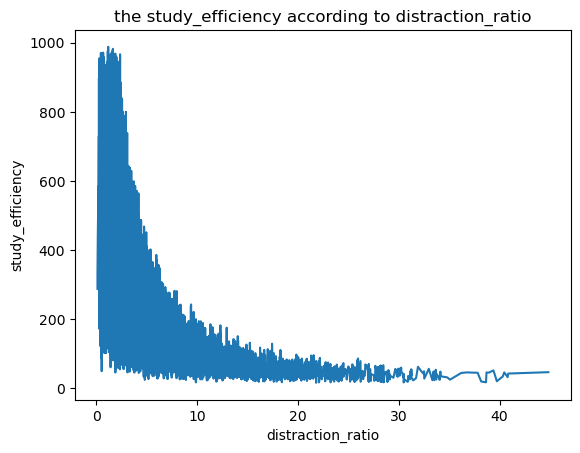

In [137]:
# Inverse relationship

sns.lineplot(y= "study_efficiency", x='distraction_ratio' , data=df)
plt.title("the study_efficiency according to distraction_ratio")


#### Which features have the strongest positive and negative correlations with productivity score?

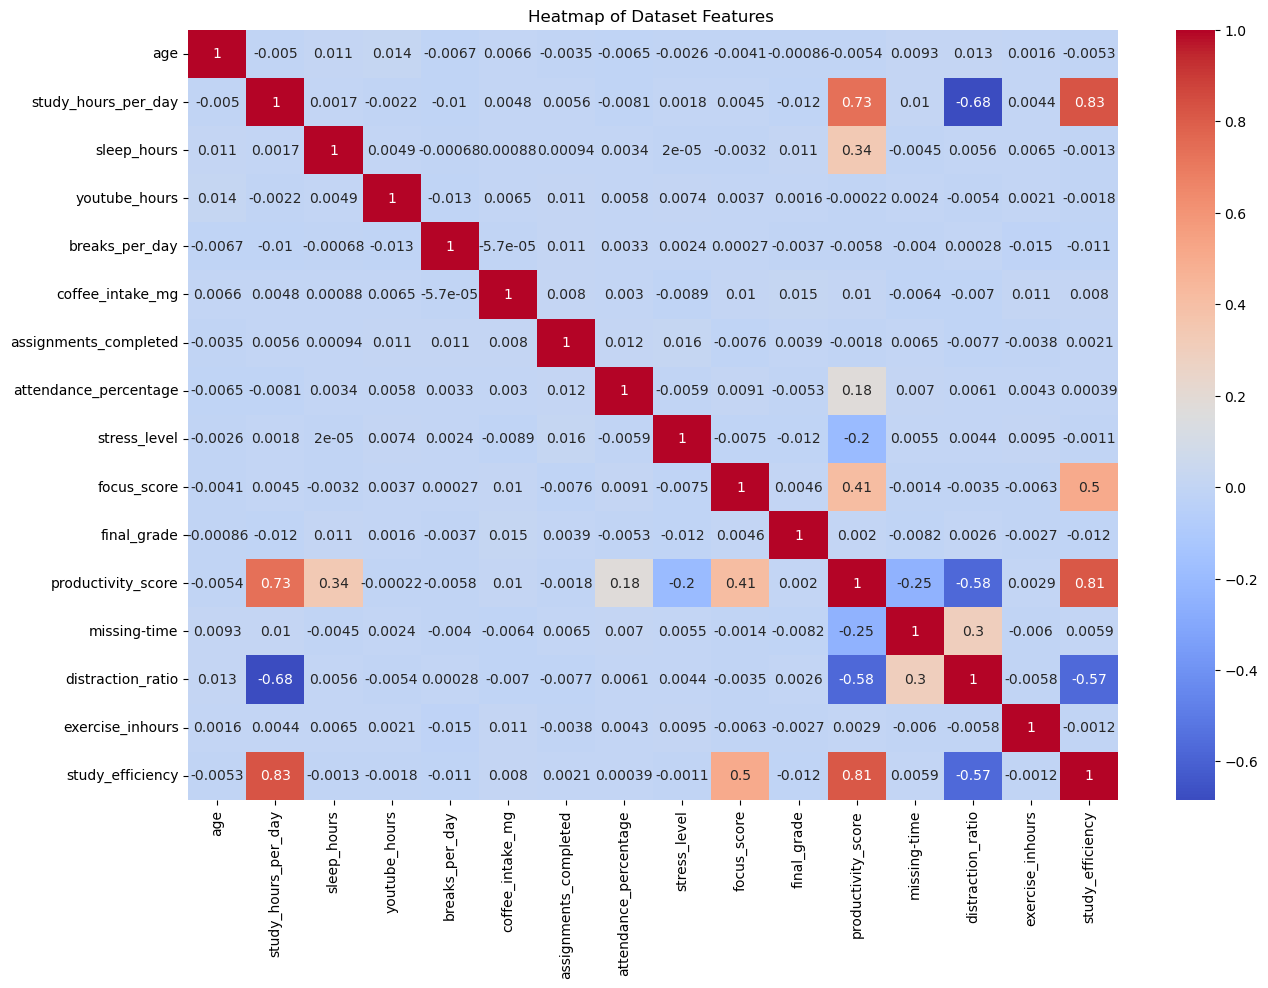

In [ ]:
# Strong relationship and understand which variables may influence the target variable (productivity score)

plt.figure(figsize=(15, 10))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Heatmap of Dataset Features ")
plt.show()

# strong positive relationship between productivity and efficiency , study hours 
# strong negative relationship between productivity and distraction ratio
# strong negative relationship between distraction ratio and study hours 

#### What are the distribution shapes of all numeric variables? Which ones appear normally distributed and which are skewed?

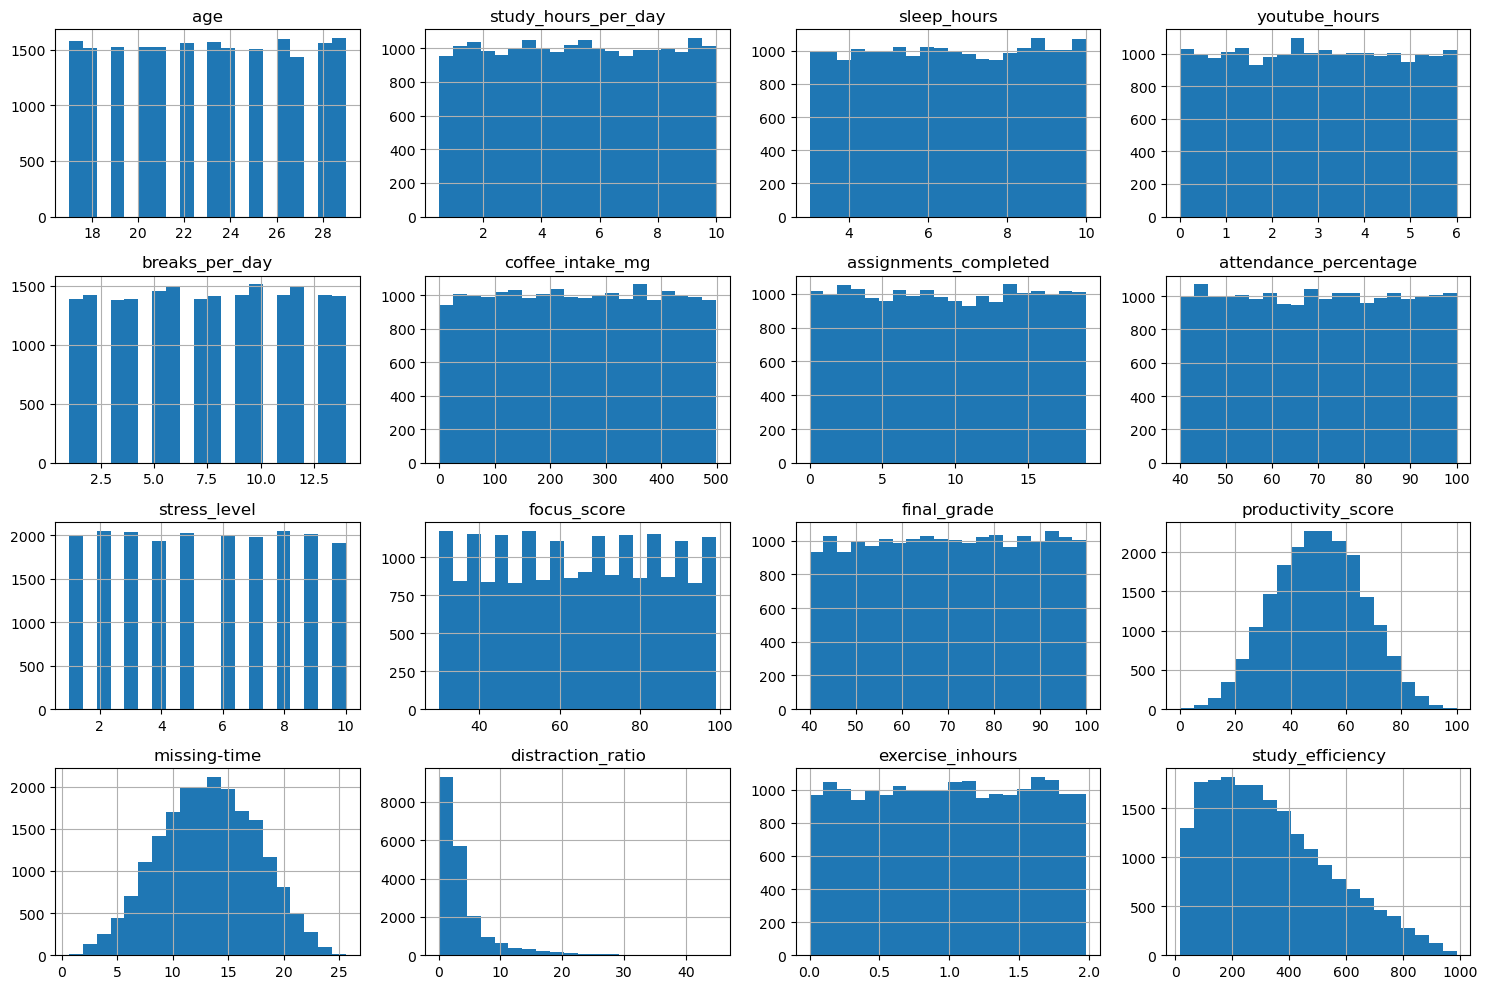

In [ ]:
# analyse the distribution of the data set and check the data normal distribution or skweness

df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()


In [140]:
# encoding gender 'categorical feature' to 'numerical feature'

le = LabelEncoder()
label = le.fit_transform(df['gender'])
label
df['gender']=label
df


,age,gender,study_hours_per_day,sleep_hours,youtube_hours,breaks_per_day,coffee_intake_mg,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score,missing-time,distraction_ratio,exercise_inhours,study_efficiency
0,23,0,4.35,3.63,1.83,6,347,2,57.21,10,57,81.87,33.78,11.37,2.613793,1.850000,247.95
1,20,1,6.14,6.58,3.13,13,403,10,91.27,10,49,60.90,48.99,8.72,1.420195,0.466667,300.86
2,29,0,4.98,3.26,0.18,1,419,8,63.14,2,38,86.22,36.60,13.17,2.644578,1.700000,189.24
3,27,0,3.19,4.58,5.75,9,178,18,40.51,6,50,71.77,19.87,16.53,5.181818,0.466667,159.50
4,24,1,7.67,6.21,5.46,8,436,7,45.53,6,41,90.13,52.90,10.26,1.337679,1.750000,314.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,26,0,4.81,7.83,2.77,6,451,11,63.69,3,89,82.13,60.43,19.47,4.047817,0.000000,428.09
19996,22,0,0.83,4.49,2.95,1,375,4,74.06,10,56,87.12,17.84,11.93,14.373494,0.216667,46.48
19997,25,1,9.36,4.33,0.35,4,413,11,73.18,9,69,81.58,65.56,11.34,1.211538,0.016667,645.84
19998,22,0,0.74,4.44,3.11,7,319,6,77.02,5,53,53.04,28.06,14.15,19.121622,0.016667,39.22


## Modeling & Evaluation

In [141]:
# splitting dataset

x=df.drop("productivity_score",axis=1)
y=df['productivity_score']
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

### LinearRegression Modeling

In [142]:
model = LinearRegression().fit(x_train,y_train)

y_train_pred =model.predict(x_train)
y_test_pred = model.predict(x_test)
r2_train = r2_score(y_train,y_train_pred)
r2_test =  r2_score(y_test,y_test_pred)
r2_train,r2_test

#good fitting

(0.9521094026625906, 0.9509543165817426)

### LinearRegression algorithm MAE

In [143]:
model = LinearRegression().fit(x_train,y_train)
y_train_pred =model.predict(x_train)
y_test_pred = model.predict(x_test)
r2_train_mae = mean_absolute_error(y_train,y_train_pred)
r2_test_mae =  mean_absolute_error(y_test,y_test_pred)
r2_train_mae,r2_test_mae

#good fitting

(2.8646364169084255, 2.905785911040959)

### RandomForest Modeling

In [144]:
rf_model =RandomForestRegressor()
rf_model.fit(x_train,y_train)
y_pred_train2 = rf_model.predict(x_train)
y_pred_test2 = rf_model.predict(x_test)
r2_train2 = r2_score(y_train,y_pred_train2)
r2_test2 =  r2_score(y_test,y_pred_test2)
r2_train2,r2_test2

#overfitting

(0.9909434560882348, 0.9347846099832574)

### XGBOOST Modeling

In [145]:
xg_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)
xg_model.fit(x_train, y_train)
y_pred1_train= xg_model.predict(x_train)
y_pred1_test = xg_model.predict(x_test)
r2_train3 = r2_score(y_train,y_pred1_train)
r2_test3=  r2_score(y_test,y_pred1_test)

r2_train3, r2_test3

#good fitting

(0.950473125206071, 0.9433191196260817)